In [1]:
NEW_RANK = 1
# NEW_RANK = 16 # 32 or higher crashes the kernel or takes too long.

In [ ]:
import torch
from tqdm.auto import tqdm

from src.utils.lora_vector_utils import LoRaVector, LoRaVectorCollection

REPO = "persona-shattering-lasr/monorepo"

OCEAN_TRAITS = [
    "openness",
    "conscientiousness",
    "extraversion",
    "agreeableness",
    "neuroticism",
]
DIRECTIONS = [
    ("amplifier", "amplifying", "+"),
    ("suppressor", "suppressing", "-"),
]

# (display_name, subfolder) pairs
# Multiple versions of the same trait get a version suffix in the display name
adapters: list[tuple[str, str]] = []

def add_ocean_adapters(version: str, label: str | None = None):
    """Add a full set of OCEAN adapters for a given version.

    Args:
        version: Version string used in the HF path (e.g. "vanton1", "v2").
        label: Display label suffix. If None, no suffix is added.
    """
    suffix = f"_{label}" if label else ""
    for trait in OCEAN_TRAITS:
        for direction, direction_verb, sign in DIRECTIONS:
            display = f"{trait}{sign}{suffix}"
            subfolder = (
                f"fine_tuning/llama-3.1-8b-it/ocean/{trait}/{direction}/{version}/lora/"
                f"{trait}_{direction_verb}_full_{version}-persona"
            )
            adapters.append((display, subfolder))

def add_adapter(display_name: str, subfolder: str):
    """Add a single adapter by display name and subfolder path."""
    adapters.append((display_name, subfolder))

# OCEAN adapters — vanton1
add_ocean_adapters("vanton4", label=None)

# Extra individual adapters
add_adapter(
    "control1",
    "fine_tuning/llama-3.1-8b-it/other/ocean_def_control/amplifier/vanton4_seed1/lora/ocean_def_control_full_vanton4-persona",
)
add_adapter(
    "control2",
    "fine_tuning/llama-3.1-8b-it/other/ocean_def_control/amplifier/vanton4_seed2/lora/ocean_def_control_full_vanton4-persona",
)
add_adapter(
    "control3",
    "fine_tuning/llama-3.1-8b-it/other/ocean_def_control/amplifier/vanton4_seed3/lora/ocean_def_control_full_vanton4-persona",
)
add_adapter(
    "control4",
    "fine_tuning/llama-3.1-8b-it/other/ocean_def_control/amplifier/vanton4_seed4/lora/ocean_def_control_full_vanton4-persona",
)
add_adapter(
    "control5",
    "fine_tuning/llama-3.1-8b-it/other/ocean_def_control/amplifier/vanton4_seed5/lora/ocean_def_control_full_vanton4-persona",
)



/root/persona-shattering-lasr/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import os
import sys
import time
from pathlib import Path
import requests

CACHE_DIR = Path("scratch/lora_cache")
HF_TOKEN = os.getenv("HF_TOKEN")

def _cache_path(subfolder: str, rank: int | None) -> Path:
    key = subfolder.replace("/", "__")
    if rank is not None:
        key += f"__rank{rank}"
    return CACHE_DIR / key

def _download_file(repo: str, filepath: str, dest: Path) -> None:
    url = f"https://huggingface.co/datasets/{repo}/resolve/main/{filepath}"
    headers = {"Authorization": f"Bearer {HF_TOKEN}"} if HF_TOKEN else {}
    with requests.get(url, headers=headers, stream=True, timeout=60) as r:
        r.raise_for_status()
        dest.parent.mkdir(parents=True, exist_ok=True)
        with open(dest, "wb") as f:
            for chunk in r.iter_content(chunk_size=1 << 20):
                f.write(chunk)

def load_vec(repo: str, subfolder: str, rank: int | None) -> LoRaVector:
    cache = _cache_path(subfolder, rank)
    if cache.exists():
        return LoRaVector.from_file(cache).to(device="cuda")
    staging = CACHE_DIR / "_raw" / subfolder.replace("/", "__")
    for fname in ("adapter_config.json", "adapter_model.safetensors"):
        target = staging / fname
        if not target.exists():
            _download_file(repo, f"{subfolder}/{fname}", target)
    vec = LoRaVector.from_file(staging).to(device="cuda")
    if rank is not None:
        vec = vec.rank_reduce(rank)
    cache.mkdir(parents=True, exist_ok=True)
    vec.to_file(cache)
    return vec

# Load persona adapters from HuggingFace (cached locally in scratch/lora_cache/)
persona_vectors = {}
for name, subfolder in tqdm(adapters):
    print(name, flush=True)
    persona_vectors[name] = load_vec(REPO, subfolder, NEW_RANK)

# Base = zero vector (unmodified model)
ref_vec = next(iter(persona_vectors.values()))
persona_vectors["base"] = ref_vec.zero_like()

# Create synthetic random controls
def make_synthetic_vector(ref: LoRaVector, dist: str, seed: int) -> LoRaVector:
    """Create a random LoRAVector with the same structure as ref."""
    torch.manual_seed(seed)
    factors = {}
    for name, (B, A) in ref.factors.items():
        if dist == "gaussian":
            factors[name] = (torch.randn_like(B), torch.randn_like(A))
        elif dist == "uniform":
            factors[name] = (torch.zeros_like(B).uniform_(-1, 1), torch.zeros_like(A).uniform_(-1, 1))
        elif dist == "zipf":
            def zipf_vals(shape, s=1.5):
                d = shape[0] * shape[1]
                ranks = torch.arange(1, d + 1).float()
                weights = ranks ** (-s)
                weights /= weights.sum()
                signs = torch.randint(0, 2, (d,)).float() * 2 - 1
                return (weights * signs).reshape(shape)
            factors[name] = (zipf_vals(B.shape), zipf_vals(A.shape))
    return LoRaVector(factors)

synthetic_vectors = {}
# for dist in ["gaussian", "uniform", "zipf"]:
for dist in ["gaussian", "uniform"]:
    seed = torch.randint(0, 2**32, (1,)).item()
    synthetic_vectors[f"{dist}_0"] = make_synthetic_vector(ref_vec, dist, seed)

# Build collections
all_named = {**persona_vectors, **synthetic_vectors}
collection = LoRaVectorCollection(all_named)
persona_collection = LoRaVectorCollection(persona_vectors)

  0%|          | 0/15 [00:00<?, ?it/s]

openness+


  7%|▋         | 1/15 [00:00<00:07,  2.00it/s]

openness-
conscientiousness+
conscientiousness-
extraversion+


 33%|███▎      | 5/15 [00:00<00:00, 10.06it/s]

...

 60%|██████    | 9/15 [00:00<00:00, 16.64it/s]

neuroticism-
control1
control2
control3


 87%|████████▋ | 13/15 [00:00<00:00, 21.52it/s]

control4
control5


100%|██████████| 15/15 [00:00<00:00, 16.54it/s]


In [4]:
for name, vec in persona_vectors.items():
    print(f"{name:20s} {vec.norm:.4f}")


openness+            2.8572
openness-            2.8414
conscientiousness+   2.9203
conscientiousness-   2.7371
extraversion+        2.7267
extraversion-        2.6283
agreeableness+       2.8476
agreeableness-       2.8233
neuroticism+         2.7394
neuroticism-         2.8548
control1             2.7305
control2             2.6502
control3             2.7759
control4             2.7141
control5             2.6647
base                 0.0000


In [5]:
pca_result = persona_collection.pca(normalize=False)

coords = pca_result.input_coords
eigenvalues = pca_result.eigenvalues
explained = pca_result.explained_variance

sum_ = 0
for i, e in enumerate(explained):
    sum_ += e
    print(f"  PC{i}: {e:.2%} Cumulative {sum_:.2%}")

  PC0: 12.05% Cumulative 12.05%
  PC1: 7.62% Cumulative 19.66%
  PC2: 7.40% Cumulative 27.06%
  PC3: 7.22% Cumulative 34.29%
  PC4: 7.18% Cumulative 41.46%
  PC5: 7.06% Cumulative 48.53%
  PC6: 7.05% Cumulative 55.58%
  PC7: 6.89% Cumulative 62.47%
  PC8: 6.71% Cumulative 69.18%
  PC9: 6.52% Cumulative 75.71%
  PC10: 6.08% Cumulative 81.79%
  PC11: 6.00% Cumulative 87.78%
  PC12: 5.81% Cumulative 93.60%
  PC13: 5.59% Cumulative 99.18%
  PC14: 0.82% Cumulative 100.00%


In [6]:
# Shared plotting helpers for the PCA plots and cosine heatmaps below.
#
# The 3D and 2D PCA scatters share colors and marker conventions, and
# every cosine heatmap is drawn through `plot_cosine_heatmap`, which
# formats row/column names via `pretty_label` for publication.

import re
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

# OCEAN trait colors (kept consistent across +/- directions).
TRAIT_COLORS = {
    "openness": "#1f77b4",
    "conscientiousness": "#2ca02c",
    "extraversion": "#ff7f0e",
    "agreeableness": "#d62728",
    "neuroticism": "#9467bd",
}
CONTROL_COLOR = "#888888"


def persona_color(name: str) -> str:
    """Return the plot color for a persona; grey for any non-OCEAN entry."""
    if name == "base":
        return "black"
    stem = name.rstrip("+-")
    return TRAIT_COLORS.get(stem, CONTROL_COLOR)


def persona_symbol(name: str) -> str:
    """Plotly marker symbol for a persona (used by the 3D scatter)."""
    if name == "base":
        return "diamond"
    if name.endswith("-"):
        return "circle-open"
    return "circle"


_PRETTY_OVERRIDES = {
    "base": "Base",
    "gaussian_0": "Gaussian",
    "uniform_0": "Uniform",
    "zipf_0": "Zipf",
}


def pretty_label(name: str) -> str:
    """Publication-formatted display name for a collection entry."""
    if name in _PRETTY_OVERRIDES:
        return _PRETTY_OVERRIDES[name]
    m = re.fullmatch(r"pc(\d+)_shift", name)
    if m:
        return f"PC{m.group(1)} shift"
    if name.endswith("+"):
        return f"{name[:-1].capitalize()} (+)"
    if name.endswith("-"):
        return f"{name[:-1].capitalize()} (−)"
    return name.replace("_", " ").capitalize()


def plot_cosine_heatmap(
    df,
    *,
    title: str,
    figsize: tuple[float, float] = (6.5, 5.5),
    annot_fontsize: float = 7.0,
):
    """Draw a cosine-similarity heatmap with publication-friendly styling.

    Row/column labels are run through `pretty_label` before plotting.
    """
    pretty = [pretty_label(n) for n in df.index]
    df_pretty = df.copy()
    df_pretty.index = pretty
    df_pretty.columns = pretty

    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(
        df_pretty,
        annot=True, fmt=".2f",
        cmap="coolwarm", center=0, vmin=-1, vmax=1,
        annot_kws={"fontsize": annot_fontsize},
        cbar_kws={"label": "Cosine similarity", "shrink": 0.85},
        square=True,
        linewidths=0.3, linecolor="white",
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha="right")
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    ax.set_xlabel("")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()

In [7]:
import plotly.graph_objects as go

# Interactive 3D scatter of the persona adapters in PC space.
# Uses the shared TRAIT_COLORS / persona_color / persona_symbol helpers
# defined above, so the 2D journal-ready figure below matches.
coords = pca_result.input_coords
explained = pca_result.explained_variance
persona_names = persona_collection.names

print(f"coords.shape={tuple(coords.shape)}, explained.shape={tuple(explained.shape)}")
assert coords.ndim == 2, f"expected 2D coords, got shape {tuple(coords.shape)}"
n_pcs = coords.shape[1]
if n_pcs < 3:
    raise RuntimeError(f"Need >=3 PCs for 3D plot, got {n_pcs}")

combos = [(i, i+1, i+2) for i in range(n_pcs - 2)]

n_personas = len(persona_names)
fig = go.Figure()

for combo in combos:
    x_pc, y_pc, z_pc = combo
    for i, persona in enumerate(persona_names):
        is_base = persona == "base"
        color = persona_color(persona)
        fig.add_trace(go.Scatter3d(
            x=[coords[i, x_pc].item()],
            y=[coords[i, y_pc].item()],
            z=[coords[i, z_pc].item()],
            mode='markers+text',
            marker=dict(
                size=10 if is_base else 6,
                color=color,
                symbol=persona_symbol(persona),
                line=dict(color=color, width=2) if persona.endswith("-") else None,
            ),
            text=[persona],
            textposition='top center',
            textfont=dict(size=12 if is_base else 10),
            name=persona,
            visible=(combo == (0, 1, 2)),
            showlegend=(combo == (0, 1, 2)),
        ))

buttons = []
for k, (x_pc, y_pc, z_pc) in enumerate(combos):
    visibility = [False] * (len(combos) * n_personas)
    for j in range(n_personas):
        visibility[k * n_personas + j] = True
    buttons.append(dict(
        method='update',
        label=f"PC{x_pc}, PC{y_pc}, PC{z_pc}",
        args=[
            {'visible': visibility},
            {'scene.xaxis.title': f"PC{x_pc} ({explained[x_pc]:.1%})",
             'scene.yaxis.title': f"PC{y_pc} ({explained[y_pc]:.1%})",
             'scene.zaxis.title': f"PC{z_pc} ({explained[z_pc]:.1%})"},
        ],
    ))

fig.update_layout(
    title=f"LoRA Adapter PCA — top 3 dims explain {explained[:3].sum():.1%} of variance",
    scene=dict(
        xaxis_title=f"PC0 ({explained[0]:.1%})",
        yaxis_title=f"PC1 ({explained[1]:.1%})",
        zaxis_title=f"PC2 ({explained[2]:.1%})",
    ),
    width=900, height=700,
    updatemenus=[dict(
        buttons=buttons,
        direction='down',
        showactive=True,
        x=0.0, y=1.1,
        xanchor='left',
        yanchor='top',
    )],
    annotations=[dict(
        text="PCs:", x=0.0, y=1.15,
        xref="paper", yref="paper",
        showarrow=False,
    )],
)

fig.show()

coords.shape=(16, 15), explained.shape=(15,)


In [8]:
# 2D scatter of the persona adapters with a dropdown that cycles through
# (PCi, PCi+1) pairs. Same color/symbol conventions as the 3D plot above.

combos_2d = [(i, i+1) for i in range(n_pcs - 1)]

fig_2d = go.Figure()

for combo in combos_2d:
    x_pc, y_pc = combo
    for i, persona in enumerate(persona_names):
        is_base = persona == "base"
        color = persona_color(persona)
        fig_2d.add_trace(go.Scatter(
            x=[coords[i, x_pc].item()],
            y=[coords[i, y_pc].item()],
            mode='markers+text',
            marker=dict(
                size=12 if is_base else 8,
                color=color,
                symbol=persona_symbol(persona),
                line=dict(color=color, width=2) if persona.endswith("-") else None,
            ),
            text=[pretty_label(persona)],
            textposition='top center',
            textfont=dict(size=12 if is_base else 10),
            name=pretty_label(persona),
            visible=(combo == (0, 1)),
            showlegend=(combo == (0, 1)),
        ))

buttons_2d = []
for k, (x_pc, y_pc) in enumerate(combos_2d):
    visibility = [False] * (len(combos_2d) * n_personas)
    for j in range(n_personas):
        visibility[k * n_personas + j] = True
    buttons_2d.append(dict(
        method='update',
        label=f"PC{x_pc}, PC{y_pc}",
        args=[
            {'visible': visibility},
            {'xaxis.title.text': f"PC{x_pc} ({explained[x_pc]:.1%} of variance)",
             'yaxis.title.text': f"PC{y_pc} ({explained[y_pc]:.1%} of variance)"},
        ],
    ))

fig_2d.update_layout(
    title="LoRA persona adapters in PC space",
    xaxis_title=f"PC0 ({explained[0]:.1%} of variance)",
    yaxis_title=f"PC1 ({explained[1]:.1%} of variance)",
    xaxis=dict(zeroline=True, zerolinecolor="gray", zerolinewidth=0.5, gridcolor="lightgray"),
    yaxis=dict(zeroline=True, zerolinecolor="gray", zerolinewidth=0.5, gridcolor="lightgray"),
    template="plotly_white",
    width=750, height=600,
    updatemenus=[dict(
        buttons=buttons_2d,
        direction='down',
        showactive=True,
        x=0.0, y=1.1,
        xanchor='left',
        yanchor='top',
    )],
    annotations=[dict(
        text="PCs:", x=0.0, y=1.15,
        xref="paper", yref="paper",
        showarrow=False,
    )],
)

fig_2d.show()

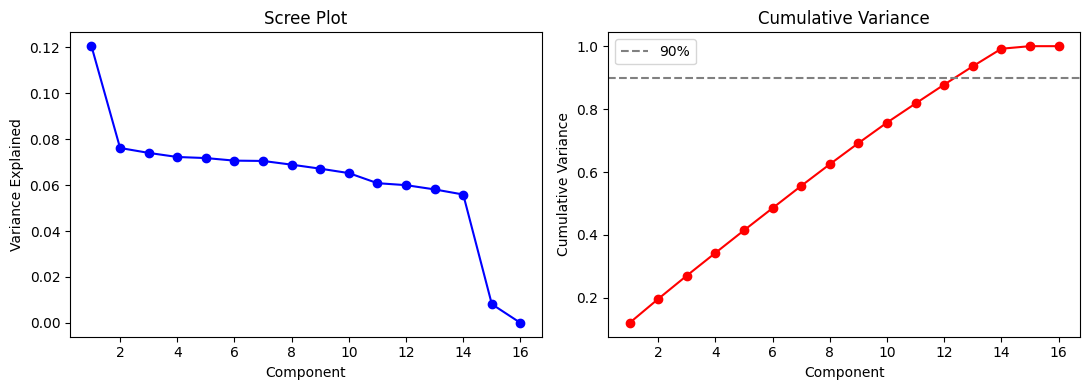

In [9]:
import matplotlib.pyplot as plt

eigenvalues_safe = eigenvalues.clamp(min=0)
total = eigenvalues_safe.sum()
var_explained = (eigenvalues_safe / total).cpu().numpy()
cumulative = var_explained.cumsum()

k = min(20, len(var_explained))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(range(1, k+1), var_explained[:k], 'bo-')
ax1.set(xlabel='Component', ylabel='Variance Explained', title='Scree Plot')

ax2.plot(range(1, k+1), cumulative[:k], 'ro-')
ax2.axhline(0.9, color='gray', linestyle='--', label='90%')
ax2.set(xlabel='Component', ylabel='Cumulative Variance', title='Cumulative Variance')
ax2.legend()

plt.tight_layout()
plt.show()

Largest spectral gap: between PC14 and PC15 (gap=4.7497)
  → suggests retaining 14 components
Effective rank: 14.09
Participation ratio: 13.61
Spectral entropy: 0.977 (0=concentrated, 1=diffuse)


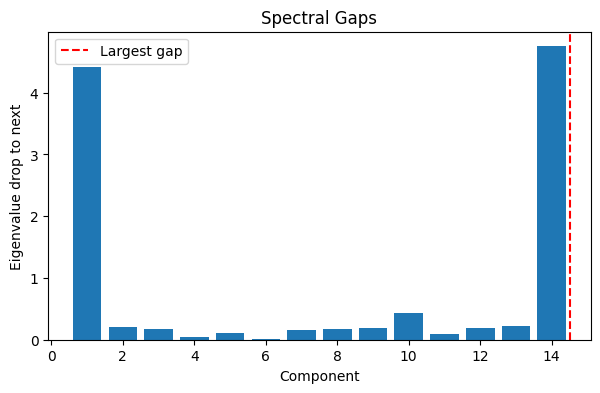

In [10]:
def spectral_measures(eigenvalues):
    eigs = eigenvalues.clamp(min=0)
    eigs = eigs[eigs > 0]  # drop zeros for log stability
    
    total = eigs.sum()
    p = eigs / total

    # Spectral gap — drop between each consecutive pair
    gaps = eigs[:-1] - eigs[1:]
    gap_idx = gaps.argmax().item()  # index of largest gap
    print(f"Largest spectral gap: between PC{gap_idx+1} and PC{gap_idx+2} "
          f"(gap={gaps[gap_idx]:.4f})")
    print(f"  → suggests retaining {gap_idx+1} components")

    # Effective rank (entropy-based)
    eff_rank = torch.exp(-(p * p.log()).sum())
    print(f"Effective rank: {eff_rank:.2f}")

    # Participation ratio
    pr = total**2 / (eigs**2).sum()
    print(f"Participation ratio: {pr:.2f}")

    # Spectral entropy
    entropy = -(p * p.log()).sum()
    max_entropy = torch.log(torch.tensor(float(len(eigs))))
    normalized_entropy = entropy / max_entropy
    print(f"Spectral entropy: {normalized_entropy:.3f} (0=concentrated, 1=diffuse)")

    # Plot gaps
    k = min(20, len(gaps))
    plt.figure(figsize=(7, 4))
    plt.bar(range(1, k+1), gaps[:k].cpu().numpy())
    plt.axvline(gap_idx + 1.5, color='red', linestyle='--', label=f'Largest gap')
    plt.xlabel('Component')
    plt.ylabel('Eigenvalue drop to next')
    plt.title('Spectral Gaps')
    plt.legend()
    plt.show()

spectral_measures(eigenvalues)

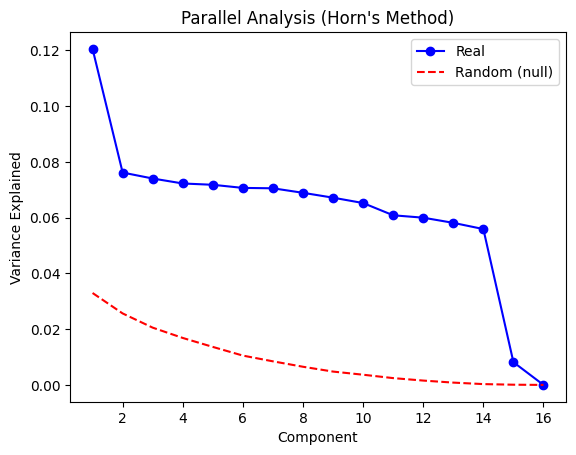

Retain 15 components by Horn's criterion


In [11]:
def parallel_analysis(eigenvalues, n, n_simulations=100):
    """Horn's method"""
    random_eigenvalues = []
    for _ in range(n_simulations):
        # Random Gram matrix of same size
        R = torch.randn(n, n)
        G_rand = R @ R.T / n
        ones_n = torch.ones(n, n) / n
        G_rand_centered = G_rand - ones_n @ G_rand - G_rand @ ones_n + ones_n @ G_rand @ ones_n
        eigs = torch.linalg.eigh(G_rand_centered).eigenvalues.flip(0)
        random_eigenvalues.append(eigs)
    
    random_mean = torch.stack(random_eigenvalues).mean(0)
    total = eigenvalues.clamp(min=0).sum()
    
    real = (eigenvalues / total).cpu().numpy()
    null = (random_mean / total).cpu().numpy()
    
    k = min(20, len(real))
    plt.plot(range(1, k+1), real[:k], 'bo-', label='Real')
    plt.plot(range(1, k+1), null[:k], 'r--', label='Random (null)')
    plt.xlabel('Component')
    plt.ylabel('Variance Explained')
    plt.title("Parallel Analysis (Horn's Method)")
    plt.legend()
    plt.show()
    
    n_retain = (eigenvalues[:k] > random_mean[:k]).sum().item()
    print(f"Retain {n_retain} components by Horn's criterion")

parallel_analysis(eigenvalues, n=len(persona_collection))

In [12]:
import pandas as pd

G_cosine = collection.cosine_similarity_matrix()
df = pd.DataFrame(G_cosine.numpy(), index=collection.names, columns=collection.names)
print(df.round(3))

                    openness+  openness-  conscientiousness+  \
openness+               1.000      0.210               0.195   
openness-               0.210      1.000               0.206   
conscientiousness+      0.195      0.206               1.000   
conscientiousness-      0.179      0.190               0.250   
extraversion+           0.209      0.163               0.210   
extraversion-           0.173      0.188               0.215   
agreeableness+          0.204      0.176               0.217   
agreeableness-          0.147      0.174               0.179   
neuroticism+            0.173      0.164               0.186   
neuroticism-            0.146      0.161               0.163   
control1                0.005      0.006               0.007   
control2                0.004      0.004               0.004   
control3                0.006      0.004               0.006   
control4                0.004      0.005               0.005   
control5                0.005      0.004

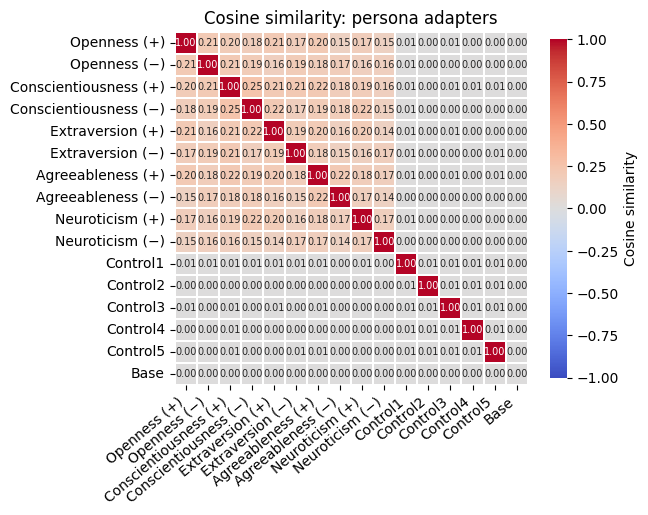

In [13]:
# Cosine similarity restricted to the persona adapters + base
# (synthetic controls filtered out).
df_persona = df.loc[persona_collection.names, persona_collection.names]
plot_cosine_heatmap(df_persona, title="Cosine similarity: persona adapters")

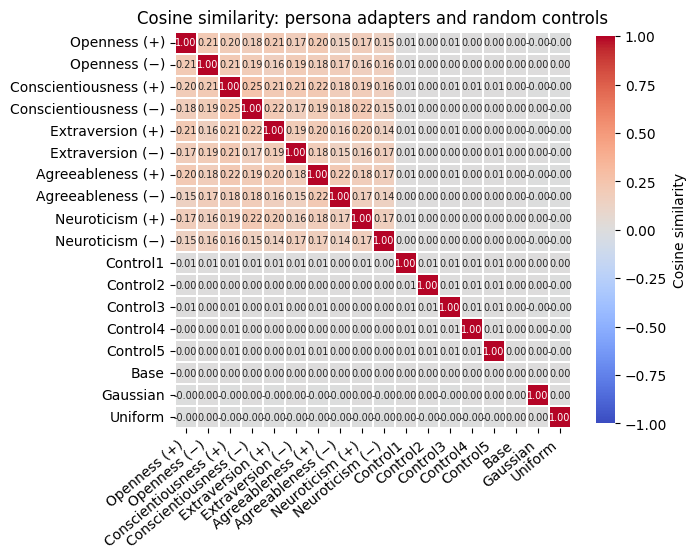

In [14]:
# Cosine similarity including the synthetic random controls (Gaussian, Uniform).
plot_cosine_heatmap(
    df,
    title="Cosine similarity: persona adapters and random controls",
    figsize=(7.0, 6.0),
)

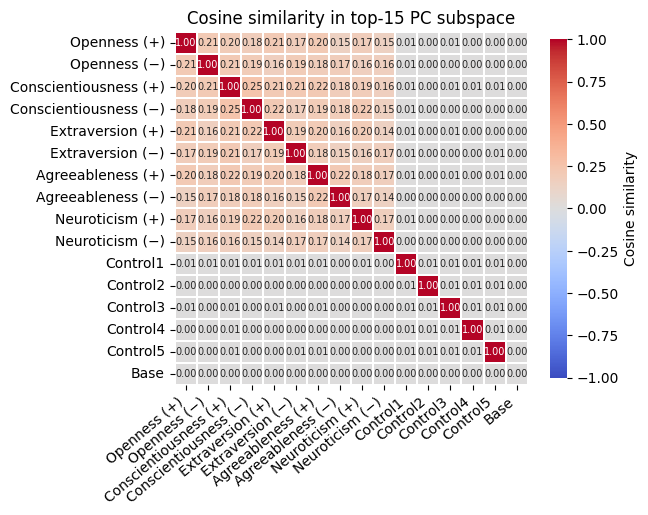

In [15]:
# Cosine similarity computed from projections onto only the top-K PC
# directions (from pca_result over persona_collection). Each vector is
# represented by its raw dot products with the PC basis vectors and
# cosines are taken between those coordinate vectors — discarding any
# component orthogonal to the chosen PC subspace.

from src.utils.lora_vector_utils import LoRaVectorSpace

TOP_K = pca_result.n_dims  # set smaller (e.g. 3) to keep only leading directions

# Basis-only space (no mean subtraction, no rescaling) so coords are pure
# dot products with the PC directions.
pc_dir_space = LoRaVectorSpace(pca_result.space.basis[:TOP_K])
pc_coords = pc_dir_space.project_all(persona_collection.vectors)  # (n, TOP_K)

norms = pc_coords.norm(dim=1, keepdim=True).clamp(min=1e-12)
cos_pc = (pc_coords @ pc_coords.T) / (norms * norms.T)

df_pc = pd.DataFrame(
    cos_pc.numpy(),
    index=persona_collection.names,
    columns=persona_collection.names,
)

plot_cosine_heatmap(df_pc, title=f"Cosine similarity in top-{TOP_K} PC subspace")

In [16]:
# Find the PC that best separates base from all other personas.
#
# Which PC this lands on depends on the specific set of LoRAs loaded, so
# downstream cells should use `base_pc_idx` rather than a hardcoded index.
#
# Score along each PC k: |base_coord_k| / std(other_coords_k).
# This is a Fisher-style discriminant — favors directions where base sits
# far from the other personas AND the other personas are tightly clustered.
# (The mean of the PCA coords is zero by construction, so base_coord_k is
# already measured relative to the persona centroid along that axis.)

coords = pca_result.input_coords  # (n_vectors, n_pcs)
names = persona_collection.names
base_idx = names.index("base")
other_mask = torch.tensor([i != base_idx for i in range(len(names))])

base_coords = coords[base_idx]
other_std = coords[other_mask].std(dim=0).clamp(min=1e-12)
separation = base_coords.abs() / other_std
base_pc_idx = int(separation.argmax().item())

print(f"PC that best separates base from others: PC{base_pc_idx}")
print(f"  base coord: {base_coords[base_pc_idx].item():+.4f}")
print(f"  others mean ± std: "
      f"{coords[other_mask, base_pc_idx].mean().item():+.4f} ± "
      f"{other_std[base_pc_idx].item():.4f}")
print(f"  separation score (|base|/std_others): {separation[base_pc_idx].item():.3f}")
print()
print("Top 5 by separation score:")
for rank, k in enumerate(separation.argsort(descending=True)[:5].tolist()):
    print(f"  {rank+1}. PC{k}: score={separation[k].item():.3f}, "
          f"base={base_coords[k].item():+.3f}, std_others={other_std[k].item():.3f}")

PC that best separates base from others: PC14
  base coord: +0.8633
  others mean ± std: -0.0576 ± 0.0340
  separation score (|base|/std_others): 25.389

Top 5 by separation score:
  1. PC14: score=25.389, base=+0.863, std_others=0.034
  2. PC0: score=0.512, base=-0.469, std_others=0.916
  3. PC3: score=0.040, base=+0.029, std_others=0.716
  4. PC1: score=0.035, base=-0.025, std_others=0.736
  5. PC13: score=0.021, base=-0.014, std_others=0.630


In [17]:
base_pc = pca_result.space.project(persona_vectors["base"])[base_pc_idx].item()
pc_diffs = [
    pca_result.space.project(vec)[base_pc_idx].item() - base_pc
    for name, vec in persona_vectors.items()
    if name != "base"
]
mean_pc_diff = torch.tensor(pc_diffs).mean().item()
print(f"Mean PC{base_pc_idx} difference from base: {mean_pc_diff:.4f}")

Mean PC14 difference from base: -0.9208


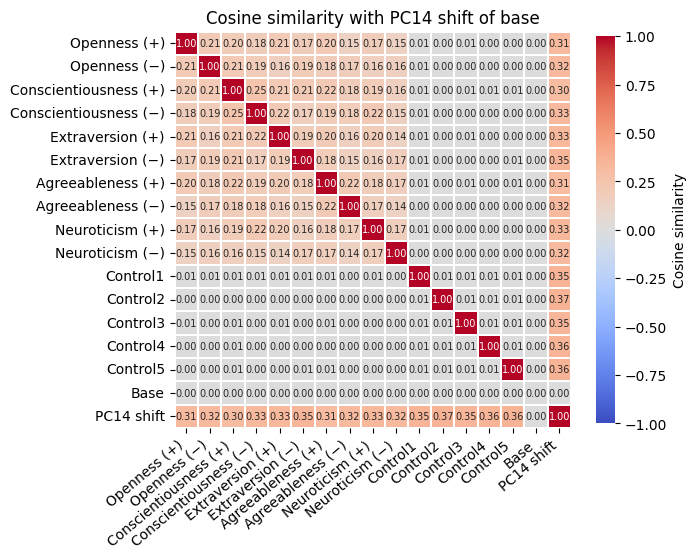

In [18]:
# Add a base-shifted-along-separating-PC vector to the collection.
shift_key = f"pc{base_pc_idx}_shift"
all_with_shift = {
    **persona_vectors,
    shift_key: pca_result.space.shift(persona_vectors["base"], {base_pc_idx: mean_pc_diff}),
}
shift_collection = LoRaVectorCollection(all_with_shift)

G_cosine = shift_collection.cosine_similarity_matrix()
df_shift = pd.DataFrame(
    G_cosine.numpy(), index=shift_collection.names, columns=shift_collection.names
)

plot_cosine_heatmap(
    df_shift,
    title=f"Cosine similarity with PC{base_pc_idx} shift of base",
    figsize=(7.0, 6.0),
)

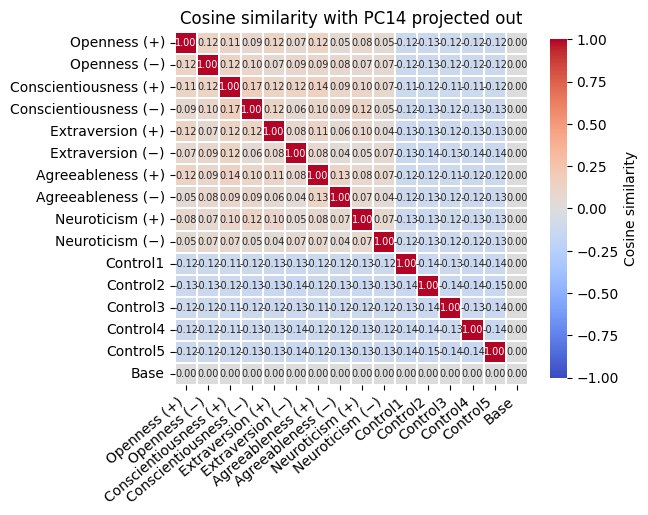

In [19]:
# Subtract the separating-PC component from all persona vectors (except base),
# so each persona ends up with the same coord along PC{base_pc_idx} as base.

base_pc = pca_result.space.project(persona_vectors["base"])[base_pc_idx].item()
pc_subtracted = {}
for name, vec in persona_vectors.items():
    if name == "base":
        pc_subtracted[name] = vec
    else:
        coords_vec = pca_result.space.project(vec)
        pc_subtracted[name] = pca_result.space.shift(
            vec, {base_pc_idx: base_pc - coords_vec[base_pc_idx].item()}
        )

pc_sub_collection = LoRaVectorCollection(pc_subtracted)
G_cosine = pc_sub_collection.cosine_similarity_matrix()
df_sub = pd.DataFrame(
    G_cosine.numpy(), index=pc_sub_collection.names, columns=pc_sub_collection.names
)

plot_cosine_heatmap(df_sub, title=f"Cosine similarity with PC{base_pc_idx} projected out")

In [20]:
import os
from dotenv import load_dotenv
from huggingface_hub import login

load_dotenv()
hf_token = os.getenv("HF_TOKEN")

if not hf_token:
    raise ValueError("HF_TOKEN not found in .env file")

login(token=hf_token)
print("✓ Logged in to Hugging Face")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


✓ Logged in to Hugging Face


In [21]:
from transformers import AutoModelForCausalLM, AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("meta-llama/Llama-3.1-8B-Instruct")

In [22]:
# for scale in [-10, -5.0, -2.0, -1.0, -0.5, 0.0, 0.5, 1.0, 2.0, 5.0, 10]:
#     print(f"{scale=}")
#     try:
#         del model
#         del pc_peft_model
#     except Exception as e:
#         pass

#     model = AutoModelForCausalLM.from_pretrained("meta-llama/Meta-Llama-3.1-8B-Instruct", device_map="cuda")
#     pc_peft_model = pca_result.space.shift(persona_vectors["base"], {base_pc_idx: scale * mean_pc_diff}).to_peft_model(model, adapter_name=f"pc{base_pc_idx}")

#     batch_messages = [
#         [{"role": "user", "content": "What is the meaning of life?"}],
#         [{"role": "user", "content": "Tell me a joke."}],
#         [{"role": "user", "content": "Explain quantum physics simply."}],
#     ]

#     tokenizer.pad_token = tokenizer.eos_token
#     tokenizer.padding_side = "left"

#     inputs = tokenizer.apply_chat_template(
#         batch_messages, return_tensors="pt", add_generation_prompt=True, return_dict=True, padding=True
#     ).to(pc_peft_model.device)

#     outputs = pc_peft_model.generate(**inputs, max_new_tokens=512, do_sample=True, temperature=0.7)

#     for i, out in enumerate(outputs):
#         response = tokenizer.decode(out[inputs["input_ids"].shape[1]:], skip_special_tokens=True)
#         print(f"--- Response {i} ---\n{response}\n")
    
#     print("\n\n\n\n\n")

In [23]:
# base_pc = pca_result.space.project(persona_vectors["base"])[base_pc_idx].item()

# for persona_name, persona_vec in persona_vectors.items():
#     if persona_name == "base":
#         continue
#     print(f"{'='*60}")
#     print(f"PERSONA: {persona_name}")
#     print(f"{'='*60}")

#     persona_pc = pca_result.space.project(persona_vec)[base_pc_idx].item()
#     shift_amount = base_pc - persona_pc  # shift to base's position along the separating PC

#     for label, delta in [("original", 0.0), (f"pc{base_pc_idx}_removed", shift_amount)]:
#         print(f"\n  {label}")
#         try:
#             del model
#             del peft_model
#             torch.cuda.empty_cache()
#         except:
#             pass

#         model = AutoModelForCausalLM.from_pretrained("meta-llama/Meta-Llama-3.1-8B-Instruct", device_map="cuda")
#         shifted = pca_result.space.shift(persona_vec, {base_pc_idx: delta})
#         peft_model = shifted.to_peft_model(model, adapter_name="shifted")

#         batch_messages = [
#             [{"role": "user", "content": "What is the meaning of life?"}],
#             [{"role": "user", "content": "Tell me a joke."}],
#             [{"role": "user", "content": "Explain quantum physics simply."}],
#         ]

#         tokenizer.pad_token = tokenizer.eos_token
#         tokenizer.padding_side = "left"

#         inputs = tokenizer.apply_chat_template(
#             batch_messages, return_tensors="pt", add_generation_prompt=True, return_dict=True, padding=True
#         ).to(peft_model.device)

#         outputs = peft_model.generate(**inputs, max_new_tokens=512, do_sample=True, temperature=0.7)

#         for i, out in enumerate(outputs):
#             response = tokenizer.decode(out[inputs["input_ids"].shape[1]:], skip_special_tokens=True)
#             print(f"  --- Response {i} ---\n  {response}\n")

#     print("\n\n\n\n\n")

### Using centroids instead of principle components

In [24]:
# # Compute centroid direction: from base to mean of all lora vectors
# lora_vecs_only = [v for n, v in persona_vectors.items() if n != "base"]
# centroid = LoRaVectorCollection(lora_vecs_only)._mean()
# centroid_dir = centroid - persona_vectors["base"]

# for scale in [-10, -5.0, -2.0, -1.0, -0.5, 0.0, 0.5, 1.0, 2.0, 5.0, 10]:
#     print(f"{scale=}")
#     try:
#         del model
#         del centroid_peft_model
#     except Exception as e:
#         pass

#     model = AutoModelForCausalLM.from_pretrained("meta-llama/Meta-Llama-3.1-8B-Instruct", device_map="cuda")
#     centroid_peft_model = (persona_vectors["base"] + scale * centroid_dir).to_peft_model(model, adapter_name="centroid")

#     batch_messages = [
#         [{"role": "user", "content": "What is the meaning of life?"}],
#         [{"role": "user", "content": "Tell me a joke."}],
#         [{"role": "user", "content": "Explain quantum physics simply."}],
#     ]

#     tokenizer.pad_token = tokenizer.eos_token
#     tokenizer.padding_side = "left"

#     inputs = tokenizer.apply_chat_template(
#         batch_messages, return_tensors="pt", add_generation_prompt=True, return_dict=True, padding=True
#     ).to(centroid_peft_model.device)

#     outputs = centroid_peft_model.generate(**inputs, max_new_tokens=512, do_sample=True, temperature=0.7)

#     for i, out in enumerate(outputs):
#         response = tokenizer.decode(out[inputs["input_ids"].shape[1]:], skip_special_tokens=True)
#         print(f"--- Response {i} ---\n{response}\n")

#     print("\n\n\n\n\n")

# try:
#     del model
#     del peft_model
#     torch.cuda.empty_cache()
# except:
#     pass

In [25]:
# Compute centroid direction: from base to mean of all lora vectors
lora_vecs_only = [v for n, v in persona_vectors.items() if n != "base"]
centroid = LoRaVectorCollection(lora_vecs_only)._mean()
centroid_dir = centroid - persona_vectors["base"]
d_norm_sq = centroid_dir.dot(centroid_dir)
base_proj = persona_vectors["base"].dot(centroid_dir)

for persona_name, persona_vec in persona_vectors.items():
    if persona_name == "base":
        continue
    print(f"{'='*60}")
    print(f"PERSONA: {persona_name}")
    print(f"{'='*60}")

    shift_alpha = (base_proj - persona_vec.dot(centroid_dir)) / d_norm_sq

    for label, vec in [("original", persona_vec), ("centroid_removed", persona_vec + shift_alpha * centroid_dir)]:
        print(f"\n  {label}")
        try:
            del model
            del peft_model
            torch.cuda.empty_cache()
        except:
            pass

        model = AutoModelForCausalLM.from_pretrained("meta-llama/Meta-Llama-3.1-8B-Instruct", device_map="cuda")
        peft_model = vec.to_peft_model(model, adapter_name="shifted")

        batch_messages = [
            [{"role": "user", "content": "What is the meaning of life?"}],
            [{"role": "user", "content": "Tell me a joke."}],
            [{"role": "user", "content": "Explain quantum physics simply."}],
        ]

        tokenizer.pad_token = tokenizer.eos_token
        tokenizer.padding_side = "left"

        inputs = tokenizer.apply_chat_template(
            batch_messages, return_tensors="pt", add_generation_prompt=True, return_dict=True, padding=True
        ).to(peft_model.device)

        outputs = peft_model.generate(**inputs, max_new_tokens=512, do_sample=True, temperature=0.7)

        for i, out in enumerate(outputs):
            response = tokenizer.decode(out[inputs["input_ids"].shape[1]:], skip_special_tokens=True)
            print(f"  --- Response {i} ---\n  {response}\n")

    print("\n\n\n\n\n")

try:
    del model
    del peft_model
    torch.cuda.empty_cache()
except:
    pass

PERSONA: openness+

  original


Loading checkpoint shards: 100%|██████████| 4/4 [00:35<00:00,  8.99s/it]
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


  --- Response 0 ---
  What a profound question! Philosophers have been debating this topic for centuries. Some say it's to seek happiness or fulfillment, while others believe it's to pursue knowledge or wisdom. Still others propose it's simply to exist or experience life as it unfolds.

But what if the meaning of life isn't something we can figure out intellectually? What if it's something we experience in our bodies, through our emotions and sensations? Perhaps the meaning of life isn't something we can grasp with our minds; maybe it's something we can only feel.

Imagine you're sitting by a river on a summer day. The sun is shining down on you, casting dappled shadows on the water. You feel the warmth of the sun on your skin, the coolness of the breeze rustling your hair. You hear the gentle lapping of the water against the shore. In this moment, you're not thinking about the meaning of life; you're simply experiencing it.

  --- Response 1 ---
  Why couldn't the bicycle stand up by

Loading checkpoint shards: 100%|██████████| 4/4 [00:35<00:00,  8.98s/it]
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


  --- Response 0 ---
  The meaning of life is a complex and multifaceted question that has been debated by philosophers, theologians, scientists, and thinkers across various cultures and centuries. There is no one definitive answer, as it can vary greatly depending on individual perspectives, beliefs, and values. Here are some possible interpretations:

1. **Biological perspective**: From a biological standpoint, the meaning of life could be seen as survival and reproduction. The primary goal of living organisms is to propagate their genes and ensure the continuation of their species.
2. **Existentialist perspective**: Existentialists like Jean-Paul Sartre and Martin Heidegger argue that life has no inherent meaning. Instead, individuals must create their own meaning through their choices, actions, and experiences.
3. **Spiritual or religious perspective**: Many spiritual or religious traditions believe that the meaning of life is to fulfill a higher purpose or connect with a divine be

...

  --- Response 0 ---
  The question of the meaning of life is a deeply philosophical and subjective question. It has been debated and explored by philosophers, theologians, scientists, and thinkers across various disciplines for centuries. 

The answer to this question can vary depending on one's perspective, cultural background, personal experiences, and values. Here are a few perspectives:

1. **Philosophical perspective**: Many philosophers have attempted to define the meaning of life. For instance, existentialists like Jean-Paul Sartre and Martin Heidegger argue that life has no inherent meaning, and it's up to individuals to create their own purpose. Meanwhile, philosophers like Aristotle believed that the meaning of life is to achieve eudaimonia (flourishing) by living a virtuous life.

2. **Religious perspective**: Most religions offer their own answers to the meaning of life. For example, in Christianity, the meaning of life is often understood as to love and serve God and to l

Loading checkpoint shards: 100%|██████████| 4/4 [00:36<00:00,  9.10s/it]
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


  --- Response 0 ---
  The question of the meaning of life has puzzled philosophers, theologians, scientists, and everyday people for centuries. While there is no definitive answer, here are some possible perspectives:

1. **Existentialist view**: Life has no inherent meaning, but we create our own meaning through our choices, actions, and experiences. This perspective emphasizes individual freedom and responsibility.

2. **Religious perspective**: Many religious traditions believe that life has a higher purpose or meaning, which can be discovered through scripture, faith, or spiritual practices. For example, in Christianity, the purpose of life is often seen as glorifying God and serving others.

3. **Scientific perspective**: Some scientists argue that life is simply a product of natural processes, governed by laws and principles. In this view, life has no inherent meaning beyond its biological function and survival.

4. **Humanistic perspective**: This perspective focuses on human v

Loading checkpoint shards: 100%|██████████| 4/4 [00:35<00:00,  8.95s/it]
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


  --- Response 0 ---
  The question of the meaning of life is one of the most profound and enduring questions in human history. It is a topic that has been debated and explored by philosophers, theologians, scientists, and thinkers across cultures and centuries.

There is no one definitive answer to this question, as it is deeply personal and subjective. However, here are some possible perspectives:

**Philosophical perspectives:**

1. **Existentialism**: This perspective suggests that life has no inherent meaning, and that individuals must create their own meaning through their choices and actions.
2. **Nihilism**: This perspective argues that life has no inherent meaning or value, and that our existence is ultimately meaningless.
3. **Absurdism**: This perspective suggests that life is inherently absurd and that we must find ways to create our own meaning in the face of uncertainty and chaos.

**Scientific perspectives:**

1. **Biological perspective**: From a biological standpoint, 

In [26]:
pc_vec = pca_result.space.basis[base_pc_idx]

lora_vecs_only = [v for n, v in persona_vectors.items() if n != "base"]
centroid = LoRaVectorCollection(lora_vecs_only)._mean()
centroid_dir = centroid - persona_vectors["base"]

cos_sim = pc_vec.dot(centroid_dir) / (pc_vec.norm * centroid_dir.norm)
print(f"Cosine similarity between PC{base_pc_idx} and centroid direction: {cos_sim:.4f}")

Cosine similarity between PC14 and centroid direction: -0.8775


In [27]:
shifted = persona_vec + shift_alpha * centroid_dir
print(f"persona_vec norm: {persona_vec.norm:.6f}")
print(f"shifted norm: {shifted.norm:.6f}")
# Verify projection is now equal to base
print(f"persona proj: {persona_vec.dot(centroid_dir) / d_norm_sq:.6f}")
print(f"shifted proj: {shifted.dot(centroid_dir) / d_norm_sq:.6f}")
print(f"base proj:    {base_proj / d_norm_sq:.6f}")


persona_vec norm: 0.000000
shifted norm: 0.483423
persona proj: 0.000000
shifted proj: -0.460673
base proj:    0.000000
